<a href="https://colab.research.google.com/github/zaidan-khairiazhar/machine-learning-python/blob/main/ML_Method_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Statistik Deskriptif Dataset California Housing ===
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2

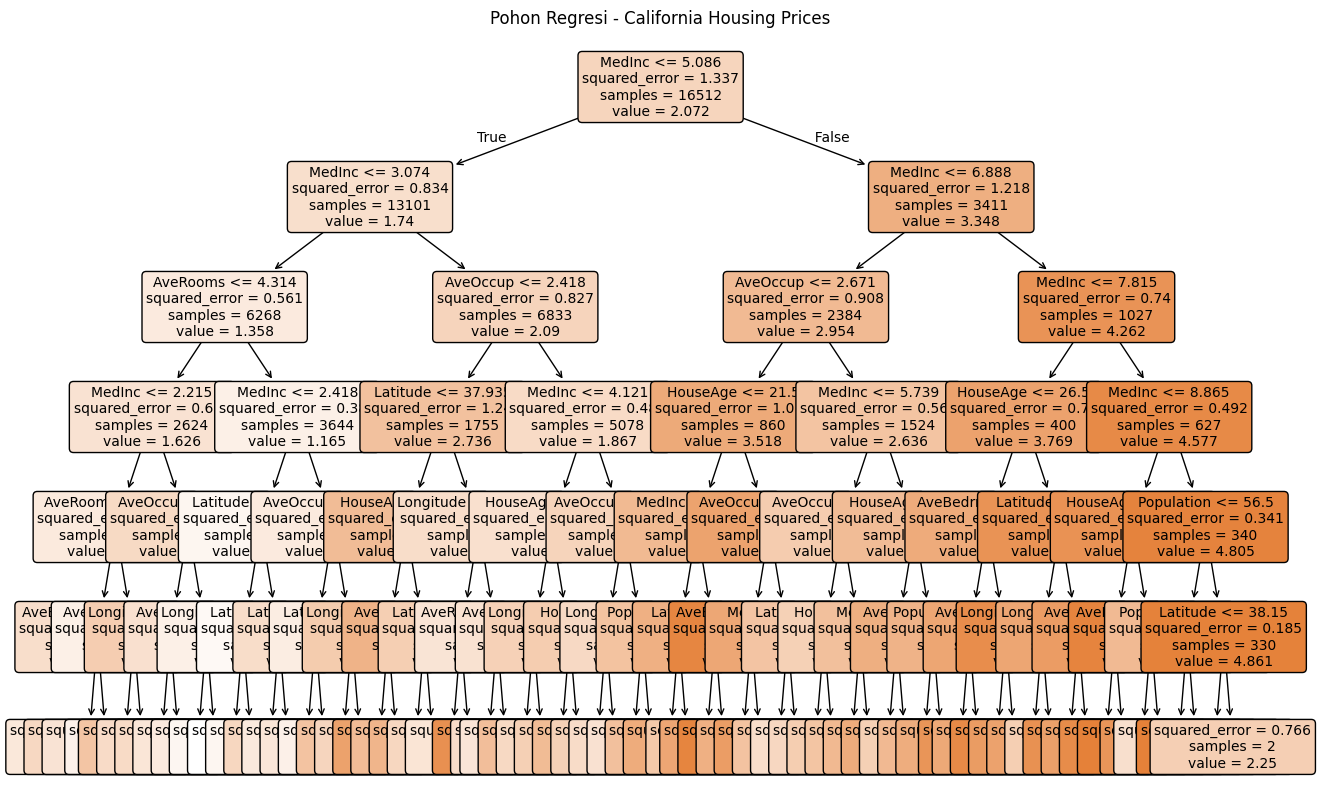

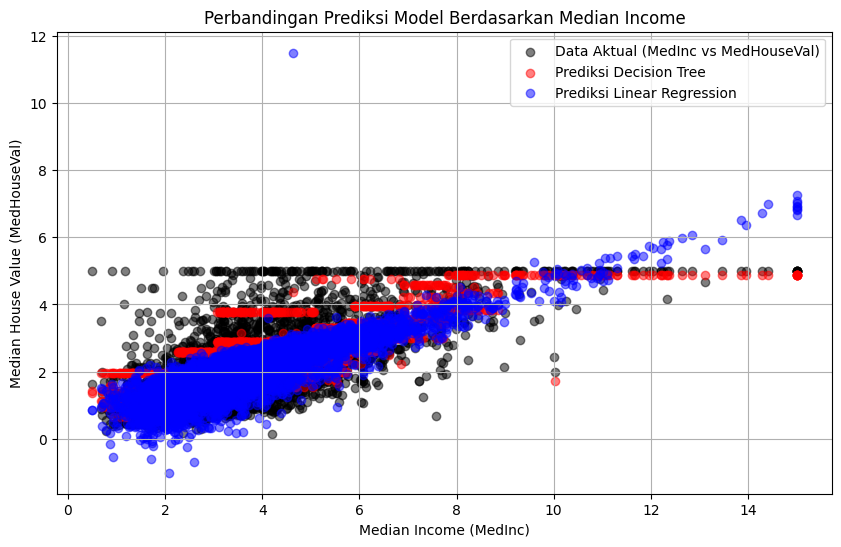

In [1]:
# --- 1. Import library ---
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt # Import matplotlib for plotting

# --- 2. Muat dataset California Housing ---
california = fetch_california_housing(as_frame=True)
df = california.frame  # langsung jadi DataFrame

# --- a. Statistik deskriptif ---
print("=== Statistik Deskriptif Dataset California Housing ===")
print(df.describe())

# --- 3. Pisahkan fitur dan target ---
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# --- 4. Split data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- b. Model Decision Tree ---
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# --- c. Evaluasi Decision Tree ---
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("\n=== Evaluasi Model Decision Tree Regressor ===")
print(f"MAE  : {mae_dt:.3f}")
print(f"RMSE : {rmse_dt:.3f}")
print(f"R²   : {r2_dt:.4f}")

# --- d. Model Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\n=== Evaluasi Model Linear Regression ===")
print(f"MAE  : {mae_lr:.3f}")
print(f"RMSE : {rmse_lr:.3f}")
print(f"R²   : {r2_lr:.4f}")

# --- e. Perbandingan ---
print("\n=== Perbandingan Kinerja Model ===")
print(f"{'Model':<20}{'MAE':<10}{'RMSE':<10}{'R² Score':<10}")
print(f"{'Decision Tree':<20}{mae_dt:<10.3f}{rmse_dt:<10.3f}{r2_dt:<10.4f}")
print(f"{'Linear Regression':<20}{mae_lr:<10.3f}{rmse_lr:<10.3f}{r2_lr:<10.4f}")

# --- f. Visualisasi Decision Tree Regressor ---
plt.figure(figsize=(15, 10))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(), # Convert to list for feature_names
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Pohon Regresi - California Housing Prices")
plt.show()

# --- g. Visualisasi hasil regresi (garis prediksi) ---
# Untuk visualisasi ini, kita akan fokus pada satu fitur utama jika dataset memiliki banyak fitur.
# Karena ini regresi multidimensi, visualisasi hubungan satu fitur dengan target lebih umum.
# Contoh: Visualisasi hubungan MedInc dengan MedHouseVal dan garis prediksi.

# Ambil MedInc dari X_test dan MedHouseVal dari y_test
X_plot = X_test['MedInc'].values.reshape(-1, 1) # Hanya ambil satu fitur untuk plotting
y_plot = y_test.values

# Prediksi menggunakan model DT dan LR untuk plot
y_pred_dt_plot = dt_model.predict(X_test)
y_pred_lr_plot = lr_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y_plot, color='black', label='Data Aktual (MedInc vs MedHouseVal)', alpha=0.5)
plt.scatter(X_plot, y_pred_dt_plot, color='red', label='Prediksi Decision Tree', alpha=0.5)
plt.scatter(X_plot, y_pred_lr_plot, color='blue', label='Prediksi Linear Regression', alpha=0.5)

plt.xlabel('Median Income (MedInc)')
plt.ylabel('Median House Value (MedHouseVal)')
plt.title('Perbandingan Prediksi Model Berdasarkan Median Income')
plt.legend()
plt.grid(True)
plt.show()